In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Data reading

In [3]:
df = pd.read_excel(r"C:\Users\hp\OneDrive\Desktop\Retail-Analytics-Platform\Data\raw.xlsx")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df.shape

(51290, 24)

In [6]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  str           
 2   Order Date      51290 non-null  datetime64[us]
 3   Ship Date       51290 non-null  datetime64[us]
 4   Ship Mode       51290 non-null  str           
 5   Customer ID     51290 non-null  str           
 6   Customer Name   51290 non-null  str           
 7   Segment         51290 non-null  str           
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  str           
 10  State           51290 non-null  str           
 11  Country         51290 non-null  str           
 12  Region          51290 non-null  str           
 13  Market          51290 non-null  str           
 14  Product ID      51290 non-null  str           
 15  Category     

In [69]:
# since the dtype of postal code is float , it should be converted into int

#### Checking for nulls

In [7]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

#### Checking for duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

#### Checking uniqueness

In [22]:
df['Order ID'].is_unique

False

In [23]:
df['Order ID'].nunique()

25728

In [17]:
df[df.duplicated(subset=['Order ID'])]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
8,40099,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,FUR-BO-5957,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",341.960,2,0.0,54.7136,25.270,High
10,36259,CA-2012-AB10015140-40974,2012-03-06,2012-03-07,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,OFF-AR-5309,Office Supplies,Art,Newell 330,17.940,3,0.0,4.6644,4.290,High
21,36260,CA-2012-AB10015140-40974,2012-03-06,2012-03-07,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,OFF-ST-3744,Office Supplies,Storage,"Carina 42""Hx23 3/4""W Media Storage Unit",242.940,3,0.0,4.8588,1.280,High
34,40976,CA-2013-AH10030140-41635,2013-12-27,2013-12-31,Standard Class,AH-100301404,Aaron Hawkins,Corporate,94122.0,San Francisco,...,OFF-ST-4291,Office Supplies,Storage,Fellowes Super Stor/Drawer Files,323.100,2,0.0,61.3890,26.700,Medium
52,40101,CA-2012-AH10030140-41273,2012-12-30,2012-12-31,First Class,AH-100301406,Aaron Hawkins,Corporate,10035.0,New York City,...,OFF-LA-3231,Office Supplies,Labels,Avery 51,18.900,3,0.0,8.6940,1.300,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51280,35112,CA-2014-ZD21925140-41829,2014-07-09,2014-07-09,Same Day,ZD-219251408,Zuschuss Donatelli,Consumer,32216.0,Jacksonville,...,OFF-PA-6474,Office Supplies,Paper,Xerox 1921,15.984,2,0.2,4.9950,2.010,Medium
51284,9922,MX-2013-KM1637593-41636,2013-12-28,2013-12-31,First Class,KM-1637593,Katherine Murray,Home Office,NaN,Managua,...,OFF-PA-5876,Office Supplies,Paper,"SanDisk Message Books, 8.5 x 11",18.640,1,0.0,8.0000,1.010,Medium
51285,29002,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,NaN,Kure,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,1.010,Medium
51287,31315,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,94109.0,San Francisco,...,OFF-AR-5321,Office Supplies,Art,Newell 341,8.560,2,0.0,2.4824,1.580,High


In [24]:
df['Customer ID'].is_unique

False

In [25]:
df['Customer ID'].nunique()

17415

In [18]:
df[df.duplicated(subset=['Customer ID'])]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
8,40099,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,FUR-BO-5957,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",341.960,2,0.0,54.7136,25.270,High
10,36259,CA-2012-AB10015140-40974,2012-03-06,2012-03-07,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,OFF-AR-5309,Office Supplies,Art,Newell 330,17.940,3,0.0,4.6644,4.290,High
16,39519,CA-2012-AB10015140-40958,2012-02-19,2012-02-25,Standard Class,AB-100151402,Aaron Bergman,Consumer,76017.0,Arlington,...,OFF-ST-3078,Office Supplies,Storage,Akro Stacking Bins,12.624,2,0.2,-2.5248,1.970,Low
21,36260,CA-2012-AB10015140-40974,2012-03-06,2012-03-07,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,OFF-ST-3744,Office Supplies,Storage,"Carina 42""Hx23 3/4""W Media Storage Unit",242.940,3,0.0,4.8588,1.280,High
34,40976,CA-2013-AH10030140-41635,2013-12-27,2013-12-31,Standard Class,AH-100301404,Aaron Hawkins,Corporate,94122.0,San Francisco,...,OFF-ST-4291,Office Supplies,Storage,Fellowes Super Stor/Drawer Files,323.100,2,0.0,61.3890,26.700,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51284,9922,MX-2013-KM1637593-41636,2013-12-28,2013-12-31,First Class,KM-1637593,Katherine Murray,Home Office,NaN,Managua,...,OFF-PA-5876,Office Supplies,Paper,"SanDisk Message Books, 8.5 x 11",18.640,1,0.0,8.0000,1.010,Medium
51285,29002,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,NaN,Kure,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,1.010,Medium
51286,34337,US-2014-ZD21925140-41765,2014-05-06,2014-05-10,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,37421.0,Chattanooga,...,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16.720,5,0.2,3.3440,1.930,High
51287,31315,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,94109.0,San Francisco,...,OFF-AR-5321,Office Supplies,Art,Newell 341,8.560,2,0.0,2.4824,1.580,High


In [26]:
df['Product ID'].is_unique

False

In [27]:
df['Product ID'].nunique()

3788

In [19]:
df[df.duplicated(subset=['Product ID'])]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
27,11645,ES-2012-EB1411048-40981,2012-03-13,2012-03-16,Second Class,EB-1411048,Eugene Barchas,Consumer,NaN,Leipzig,...,OFF-AP-4743,Office Supplies,Appliances,"Hoover Stove, Red",3069.7380,6,0.10,1364.2380,725.340,Critical
39,28046,IN-2012-DL128657-40918,2012-01-10,2012-01-11,First Class,DL-128657,Dan Lawera,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",2875.0950,5,0.10,511.0950,665.270,Medium
40,21316,ID-2014-JB1600059-41873,2014-08-22,2014-08-26,Standard Class,JB-1600059,Joy Bell-,Consumer,NaN,Mataram,...,TEC-PH-5268,Technology,Phones,"Motorola Smart Phone, Full Size",3200.5962,6,0.17,-77.2038,660.870,High
43,16681,ES-2013-GT14710139-41621,2013-12-13,2013-12-17,Standard Class,GT-14710139,Greg Tran,Consumer,NaN,Huddersfield,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",5785.0200,9,0.00,404.7300,656.730,High
54,42336,MZ-2014-DG330087-41991,2014-12-18,2014-12-18,Same Day,DG-330087,Deirdre Greer,Corporate,NaN,Maputo,...,TEC-PH-5269,Technology,Phones,"Motorola Smart Phone, with Caller ID",2582.1600,4,0.00,593.8800,627.170,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2015-KE1642066-42174,2015-06-19,2015-06-19,Same Day,KE-1642066,Katrina Edelman,Corporate,NaN,Kure,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.1000,5,0.00,4.5000,1.010,Medium
51286,34337,US-2014-ZD21925140-41765,2014-05-06,2014-05-10,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,37421.0,Chattanooga,...,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16.7200,5,0.20,3.3440,1.930,High
51287,31315,CA-2012-ZD21925140-41147,2012-08-26,2012-08-31,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,94109.0,San Francisco,...,OFF-AR-5321,Office Supplies,Art,Newell 341,8.5600,2,0.00,2.4824,1.580,High
51288,9596,MX-2013-RB1979518-41322,2013-02-17,2013-02-21,Standard Class,RB-1979518,Ross Baird,Home Office,NaN,Valinhos,...,OFF-BI-2919,Office Supplies,Binders,"Acco Index Tab, Economy",13.4400,2,0.00,2.4000,1.003,Medium


In [29]:
df['Row ID'].is_unique

True

In [20]:
df[df.duplicated(subset=['Row ID'])]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


#### Checking dtype of columns

In [30]:
num_col = df.select_dtypes(include=['number']).columns
print(num_col)

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost'],
      dtype='str')


In [32]:
cat_col = df.select_dtypes(include=['object']).columns
print(cat_col)

Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'City', 'State', 'Country', 'Region', 'Market', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Order Priority'],
      dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_14156\3942227960.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object']).columns


In [33]:
date_col = df.select_dtypes(include=['datetime']).columns
print(date_col)

Index(['Order Date', 'Ship Date'], dtype='str')


#### Negative values

In [36]:
(df['Profit']<0).sum()

np.int64(12544)

In [37]:
df[df['Profit']<0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.3950,9,0.10,-288.7650,923.630,Critical
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.5100,5,0.10,-96.5400,910.160,Medium
16,39519,CA-2012-AB10015140-40958,2012-02-19,2012-02-25,Standard Class,AB-100151402,Aaron Bergman,Consumer,76017.0,Arlington,...,OFF-ST-3078,Office Supplies,Storage,Akro Stacking Bins,12.6240,2,0.20,-2.5248,1.970,Low
30,220,US-2012-RR1952536-41270,2012-12-27,2012-12-29,Second Class,RR-1952536,Rick Reed,Corporate,NaN,Santo Domingo,...,TEC-PH-5841,Technology,Phones,"Samsung Smart Phone, VoIP",1696.6400,5,0.20,-148.4600,704.056,Critical
40,21316,ID-2014-JB1600059-41873,2014-08-22,2014-08-26,Standard Class,JB-1600059,Joy Bell-,Consumer,NaN,Mataram,...,TEC-PH-5268,Technology,Phones,"Motorola Smart Phone, Full Size",3200.5962,6,0.17,-77.2038,660.870,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51260,35398,US-2015-ZC21910140-42175,2015-06-20,2015-06-24,Standard Class,ZC-219101402,Zuschuss Carroll,Consumer,77095.0,Houston,...,OFF-AP-4739,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.4440,1,0.80,-1.1100,1.010,Medium
51266,27081,ID-2013-EK13795102-41496,2013-08-10,2013-08-11,First Class,EK-13795102,Eileen Kiefer,Home Office,NaN,Pasig,...,OFF-PA-4148,Office Supplies,Paper,"Enermax Computer Printout Paper, Multicolor",49.3020,3,0.45,-18.8280,1.030,Medium
51275,46231,ZA-2012-AS285147-40988,2012-03-20,2012-03-25,Standard Class,AS-285147,Alejandro Savely,Corporate,NaN,Harare,...,OFF-AR-5911,Office Supplies,Art,"Sanford Highlighters, Easy-Erase",9.6120,2,0.70,-21.1680,1.020,Medium
51277,46582,TU-2015-KF6285134-42337,2015-11-29,2015-11-30,First Class,KF-6285134,Karen Ferguson,Home Office,NaN,Midyat,...,OFF-AR-3546,Office Supplies,Art,"Boston Pens, Blue",34.1280,6,0.60,-49.5720,1.020,Medium


In [38]:
(df['Sales']<0).sum()

np.int64(0)

In [39]:
(df['Quantity']<0).sum()

np.int64(0)

In [40]:
(df['Discount']<0).sum()

np.int64(0)

#### Invalid Discounts

In [44]:
df[(df["Discount"]<0) | (df['Discount']>1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [43]:
invalid = ((df["Discount"]<0) | (df['Discount']>1))
print(invalid)

0        False
1        False
2        False
3        False
4        False
         ...  
51285    False
51286    False
51287    False
51288    False
51289    False
Name: Discount, Length: 51290, dtype: bool


#### Invalid Customers

In [45]:
df.groupby('Customer ID')['Customer Name'].nunique()

Customer ID
AA-10315102     1
AA-10315120     1
AA-10315139     1
AA-103151402    1
AA-103151404    1
               ..
ZD-2192548      1
ZD-2192564      1
ZD-219257       1
ZD-2192582      1
ZD-2192596      1
Name: Customer Name, Length: 17415, dtype: int64

In [46]:
df.groupby('Customer ID')['Customer Name'].nunique().loc[lambda x:x>1]

Series([], Name: Customer Name, dtype: int64)

#### Profit Inconsistent with sales

In [47]:
df[(df['Sales']==0) & (df['Profit']!=0)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [51]:
df[df['Sales']<df['Profit']]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [52]:
df[df["Sales"].isna() | df['Profit'].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [53]:
print("Profit > Sales:", (df["Profit"] > df["Sales"]).sum())
print("Sales = 0 & Profit ≠ 0:", ((df["Sales"] == 0) & (df["Profit"] != 0)).sum())
print("Negative Sales:", (df["Sales"] < 0).sum())

Profit > Sales: 0
Sales = 0 & Profit ≠ 0: 0
Negative Sales: 0


#### Timeliness

In [55]:
print("Earliest Order:", df["Order Date"].min())

Earliest Order: 2012-01-01 00:00:00


In [56]:
print("Latest Order:", df["Order Date"].max())

Latest Order: 2015-12-31 00:00:00


In [58]:
print("Earliest:", df["Order Date"].min())
print("Latest:", df["Order Date"].max())
print("Date Range:", df["Order Date"].max() - df["Order Date"].min())

Earliest: 2012-01-01 00:00:00
Latest: 2015-12-31 00:00:00
Date Range: 1460 days 00:00:00


In [59]:
future_dates = df[df["Order Date"] > pd.Timestamp.today()]
print("Number of future dates:", len(future_dates))
future_dates

Number of future dates: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


#### Integrity

In [61]:
invalid_customers = df[~df["Customer ID"].isin(df["Customer ID"])]
print("Foreign Key Issues:", len(invalid_customers))
invalid_customers

Foreign Key Issues: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [62]:
invalid_products = df[~df["Product ID"].isin(df["Product ID"])]
print("Foreign Key Issues:", len(invalid_products))
invalid_products

Foreign Key Issues: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [63]:
customer_issues = df.groupby("Customer ID")["Customer Name"].nunique()
customer_issues = customer_issues[customer_issues > 1]
print(customer_issues)

Series([], Name: Customer Name, dtype: int64)


In [64]:
product_issues = df.groupby("Product ID")["Product Name"].nunique()
product_issues = product_issues[product_issues > 1]
print(product_issues)

Series([], Name: Product Name, dtype: int64)


#### Outlier Detection

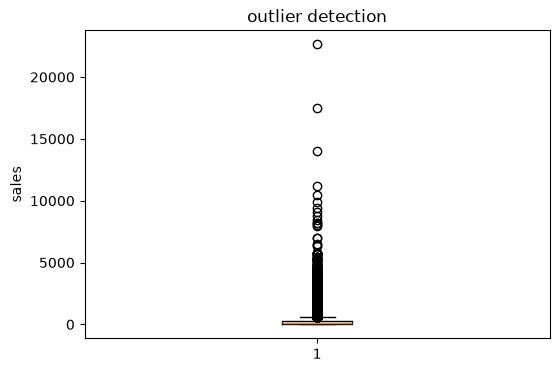

In [66]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Sales'])
plt.title("outlier detection")
plt.ylabel("sales")
plt.show()

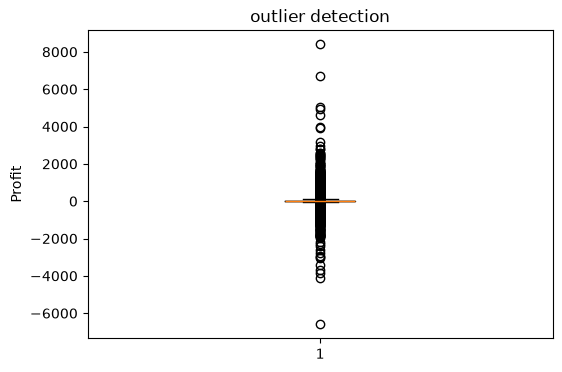

In [67]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Profit'])
plt.title("outlier detection")
plt.ylabel("Profit")
plt.show()

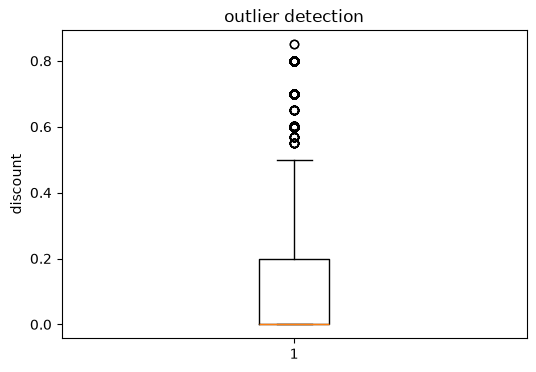

In [68]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Discount'])
plt.title("outlier detection")
plt.ylabel("discount")
plt.show()